### Xgboost from PCA, yeo v4 dataset 
### Stopping early, with 30% test set, 20% validation set and 50% training set

/var/folders/s2/_qxs1d_57r18ktd8jtkpm0sw0000gn/T/ipykernel_3710/3083542990.py:68: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['Activity_encoded'] = le.fit_transform(df['Activity'])


--- Running 10-Fold GroupKFold Cross-Validation ---
Fold 1 Val Accuracy: 0.9174 (Val Subjects: {np.int64(10), np.int64(21)})
Fold 2 Val Accuracy: 0.9679 (Val Subjects: {np.int64(2), np.int64(30)})
Fold 3 Val Accuracy: 0.9005 (Val Subjects: {np.int64(8), np.int64(28), np.int64(5)})
Fold 4 Val Accuracy: 0.9623 (Val Subjects: {np.int64(24), np.int64(7)})
Fold 5 Val Accuracy: 0.9971 (Val Subjects: {np.int64(27), np.int64(11)})
Fold 6 Val Accuracy: 0.9840 (Val Subjects: {np.int64(4), np.int64(23)})
Fold 7 Val Accuracy: 0.9666 (Val Subjects: {np.int64(17), np.int64(12)})
Fold 8 Val Accuracy: 0.8926 (Val Subjects: {np.int64(18), np.int64(6)})
Fold 9 Val Accuracy: 0.9549 (Val Subjects: {np.int64(19), np.int64(13)})
Fold 10 Val Accuracy: 0.9725 (Val Subjects: {np.int64(1), np.int64(29)})

Mean CV Accuracy: 0.9516 +/- 0.0338

--- Classification Report (Unseen Holdout Subjects) ---
                    precision    recall  f1-score   support

            LAYING       1.00      1.00      1.00      

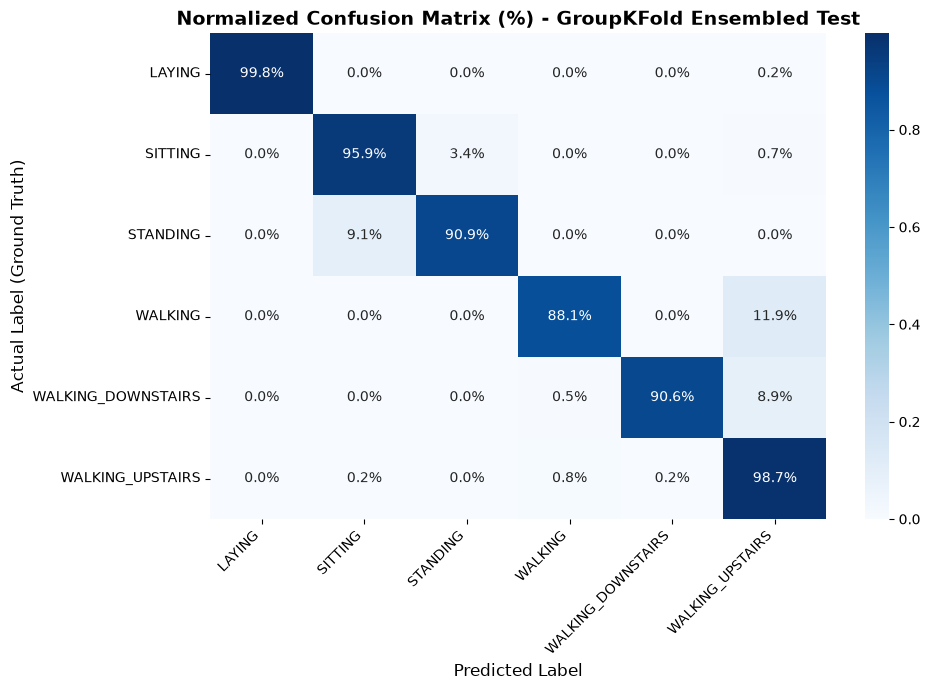

In [37]:
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.model_selection import GroupKFold, GroupShuffleSplit
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import json
import os
from datetime import datetime

# Document tracking note
note_for_docs = "10-fold GroupKFold CV on Train/Val, Tested on 30% Holdout Subjects"

def log_experiment(params, accuracy, cm_normalized, labels, filepath="../dataset/experiment_logs.jsonl", mode="jsonl"):
    """
    Logs hyperparameter tuning runs to either JSON Lines or CSV.
    
    cm_normalized: numpy array from confusion_matrix(y_test, y_pred, normalize='true')
    labels: list/array of class names from le.classes_
    """
    timestamp = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
    
    if mode == "jsonl":
        # Create dictionary representation of the confusion matrix (actual -> predicted -> %)
        cm_dict = {
            actual: {pred: round(float(cm_normalized[i, j] * 100), 2) 
                     for j, pred in enumerate(labels)}
            for i, actual in enumerate(labels)
        }
        
        entry = {
            "timestamp": timestamp,
            "accuracy": round(float(accuracy), 4),
            "hyperparameters": params,
            "confusion_matrix_pct": cm_dict,
            "note": note_for_docs
        }
        
        with open(filepath, "a") as f:
            f.write(json.dumps(entry) + "\n")
        print(f"Logged run to {filepath} (JSONL)")

    elif mode == "csv":
        # Flatten parameters and confusion matrix entries into a single dictionary row
        row = {
            "timestamp": timestamp,
            "accuracy": round(float(accuracy), 4),
            **{f"param_{k}": v for k, v in params.items()}
        }
        
        # Flatten confusion matrix percentages: cm_<actual>_<predicted>
        for i, actual in enumerate(labels):
            for j, pred in enumerate(labels):
                col_name = f"cm_{actual}_{pred}"
                row[col_name] = round(float(cm_normalized[i, j] * 100), 2)
        
        df_row = pd.DataFrame([row])
        file_exists = os.path.isfile(filepath)
        df_row.to_csv(filepath, mode="a", index=False, header=not file_exists)
        print(f"Logged run to {filepath} (CSV)")

# --- 1. Load Data & Encode Target ---
df = pd.read_csv('../dataset/full_v4_2.csv')

le = LabelEncoder()
df['Activity_encoded'] = le.fit_transform(df['Activity'])

# --- 2. Separate 30% Holdout Test Set (Unseen Subjects) ---
gss_test = GroupShuffleSplit(n_splits=1, test_size=0.30, random_state=69)
train_val_idx, test_idx = next(gss_test.split(df, groups=df['subject']))

df_train_val = df.iloc[train_val_idx].copy()
df_test = df.iloc[test_idx].copy()

drop_cols = ['subject', 'Activity', 'Activity_encoded']

X_train_val = df_train_val.drop(columns=[c for c in drop_cols if c in df_train_val.columns])
y_train_val = df_train_val['Activity_encoded']
groups_train_val = df_train_val['subject']

X_test = df_test.drop(columns=[c for c in drop_cols if c in df_test.columns])
y_test = df_test['Activity_encoded']

# --- 3. Define Hyperparameters ---
param = {
    'learning_rate': 0.05,
    'max_depth': 3,
    'n_estimators': 1000,
    'early_stopping_rounds': 15,
    'subsample': 0.5,
    'colsample_bytree': 0.8,
    'min_child_weight': 2,
    'objective': 'multi:softmax',
    'num_class': 6,
    'gamma': 0,
    'random_state': 69
}

# --- 4. Perform GroupKFold Cross-Validation ---
n_splits = 10
gkf = GroupKFold(n_splits=n_splits)

cv_accuracies = []
models = []

print(f"--- Running {n_splits}-Fold GroupKFold Cross-Validation ---")

for fold, (cv_train_idx, cv_val_idx) in enumerate(gkf.split(X_train_val, y_train_val, groups=groups_train_val)):
    X_cv_train, y_cv_train = X_train_val.iloc[cv_train_idx], y_train_val.iloc[cv_train_idx]
    X_cv_val, y_cv_val = X_train_val.iloc[cv_val_idx], y_train_val.iloc[cv_val_idx]
    
    fold_model = xgb.XGBClassifier(**param)
    fold_model.fit(
        X_cv_train, y_cv_train,
        eval_set=[(X_cv_train, y_cv_train), (X_cv_val, y_cv_val)],
        verbose=False
    )
    
    val_preds = fold_model.predict(X_cv_val)
    val_acc = accuracy_score(y_cv_val, val_preds)
    cv_accuracies.append(val_acc)
    models.append(fold_model)
    
    val_subjects = set(groups_train_val.iloc[cv_val_idx].unique())
    print(f"Fold {fold + 1} Val Accuracy: {val_acc:.4f} (Val Subjects: {val_subjects})")

print(f"\nMean CV Accuracy: {np.mean(cv_accuracies):.4f} +/- {np.std(cv_accuracies):.4f}")

# --- 5. Holdout Test Set Predictions (Ensembled Across Folds) ---
test_probs = np.zeros((len(X_test), param['num_class']))
for fold_model in models:
    test_probs += fold_model.predict_proba(X_test) / n_splits

y_pred = np.argmax(test_probs, axis=1)

labels = le.classes_
y_decoded = le.inverse_transform(y_test)
y_pred_decoded = le.inverse_transform(y_pred)

print("\n--- Classification Report (Unseen Holdout Subjects) ---")
print(classification_report(y_decoded, y_pred_decoded))

# --- 6. Compute Metrics & Execute Experiment Logging ---
accuracy = accuracy_score(y_test, y_pred)
cm_normalized = confusion_matrix(y_test, y_pred, normalize='true')

# Log the experiment run using your logging function
log_experiment(
    params=param,
    accuracy=accuracy,
    cm_normalized=cm_normalized,
    labels=labels,
    filepath="../dataset/experiment_logs.jsonl",
    mode="jsonl"
)

# --- 7. Plot Normalized Confusion Matrix ---
plt.figure(figsize=(10, 7))
sns.heatmap(
    cm_normalized, 
    annot=True, 
    fmt='.1%', 
    cmap='Blues', 
    xticklabels=labels, 
    yticklabels=labels
)

plt.title('Normalized Confusion Matrix (%) - GroupKFold Ensembled Test', fontsize=14, fontweight='bold')
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('Actual Label (Ground Truth)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

plt.show()